# United States of America Election 2020 Analysis

An in-depth data analytics project focusing on the 2020 US Presidential Election results, utilizing county-level vote breakdowns to analyze key swing states, party distribution, and regional voter behavior.

<img src='https://images.ft.com/v3/image/raw/https%3A%2F%2Fd1e00ek4ebabms.cloudfront.net%2Fproduction%2F397168c7-e2a5-49f2-80d7-b7fde5dd549e.jpg?source=next-article&fit=scale-down&quality=highest&width=700&dpr=1' width='750'>

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [2]:
df=pd.read_csv('president_county.csv')

In [3]:
df.head()

,state,county,current_votes,total_votes,percent
0,Delaware,Kent County,87025,87025,100
1,Delaware,New Castle County,287633,287633,100
2,Delaware,Sussex County,129352,129352,100
3,District of Columbia,District of Columbia,41681,41681,100
4,District of Columbia,Ward 2,32881,32881,100


In [4]:
df.tail()

,state,county,current_votes,total_votes,percent
4628,Arizona,Graham County,14996,14996,100
4629,Arizona,Greenlee County,3688,3688,100
4630,Arizona,La Paz County,7460,7460,100
4631,Arizona,Maricopa County,2069475,2068144,100
4632,Arizona,Mohave County,104705,104705,100


In [5]:
df.shape

(4633, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4633 entries, 0 to 4632
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   state          4633 non-null   object
 1   county         4633 non-null   object
 2   current_votes  4633 non-null   int64 
 3   total_votes    4633 non-null   int64 
 4   percent        4633 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 181.1+ KB


In [7]:
df.isnull().sum()

state            0
county           0
current_votes    0
total_votes      0
percent          0
dtype: int64

In [8]:
df.describe()

,current_votes,total_votes,percent
count,4.633000e+03,4.633000e+03,4633.000000
mean,3.445030e+04,3.448461e+04,99.579754
std,1.244014e+05,1.249112e+05,1.807009
min,0.000000e+00,0.000000e+00,69.000000
25%,2.327000e+03,2.326000e+03,100.000000
50%,7.765000e+03,7.695000e+03,100.000000
75%,2.034600e+04,2.034600e+04,100.000000
max,4.263443e+06,4.263443e+06,100.000000


In [9]:
df.corr(numeric_only=True)

,current_votes,total_votes,percent
current_votes,1.000000,0.999901,0.006204
total_votes,0.999901,1.000000,0.004472
percent,0.006204,0.004472,1.000000


In [10]:
df.columns

Index(['state', 'county', 'current_votes', 'total_votes', 'percent'], dtype='object')

C:\Users\furka\AppData\Local\Temp\ipykernel_12144\355504133.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_states, x='total_votes', y='state', palette='Blues_r')


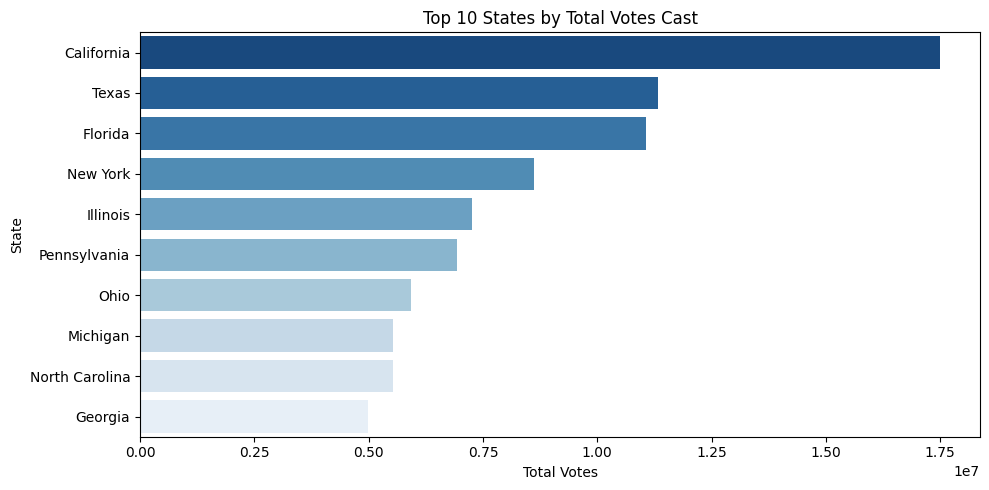

In [13]:
# Top 10 States with the Most Votes
top10_states = df.groupby('state')['total_votes'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_states, x='total_votes', y='state', palette='Blues_r')
plt.title('Top 10 States by Total Votes Cast')
plt.xlabel('Total Votes')
plt.ylabel('State')
plt.tight_layout()
plt.show()

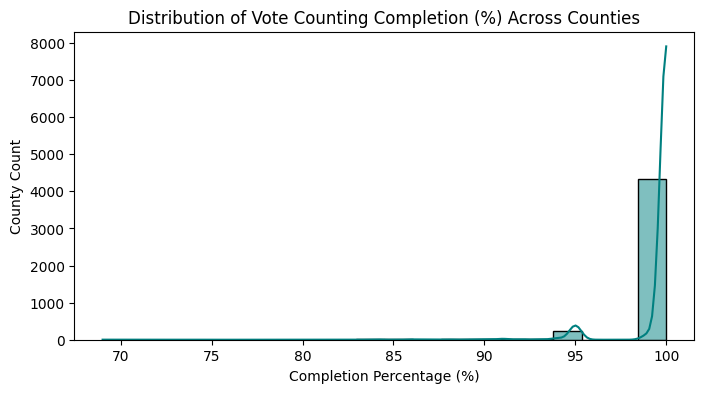

In [15]:
#Distribution of Vote Counting Completion Rates
plt.figure(figsize=(8, 4))
sns.histplot(df['percent'], kde=True, color='teal', bins=20)
plt.title('Distribution of Vote Counting Completion (%) Across Counties')
plt.xlabel('Completion Percentage (%)')
plt.ylabel('County Count')
plt.show()

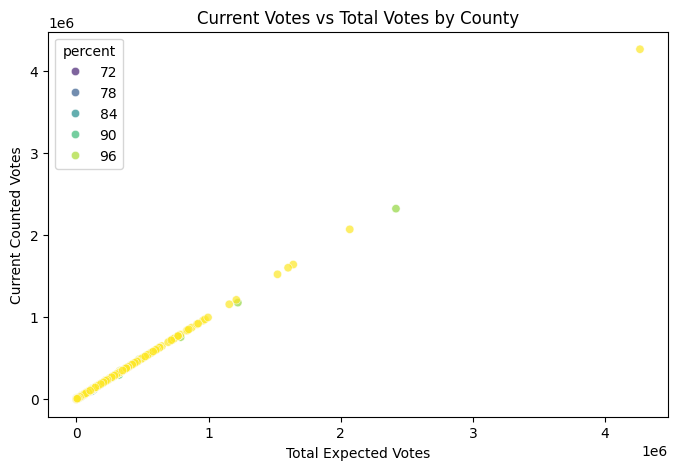

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_votes', y='current_votes', hue='percent', palette='viridis', alpha=0.7)
plt.title('Current Votes vs Total Votes by County')
plt.xlabel('Total Expected Votes')
plt.ylabel('Current Counted Votes')
plt.show()

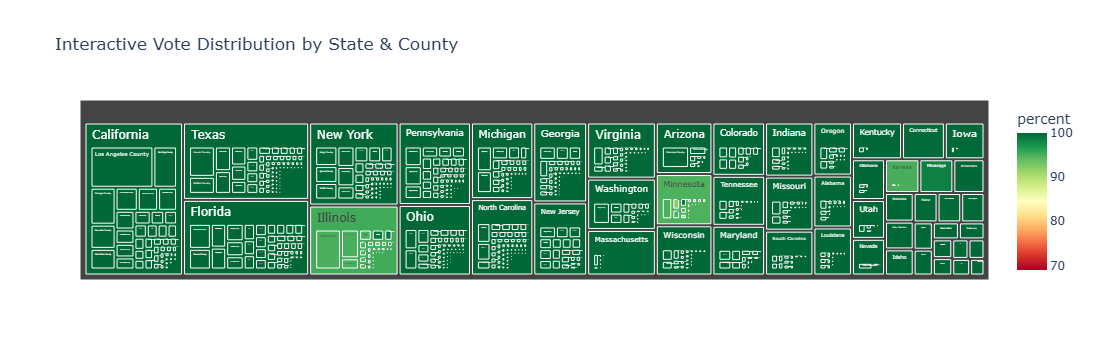

In [19]:
import plotly.express as px

fig = px.treemap(
    df, 
    path=['state', 'county'], 
    values='total_votes',
    color='percent',
    color_continuous_scale='RdYlGn',
    title='Interactive Vote Distribution by State & County'
)
fig.show()

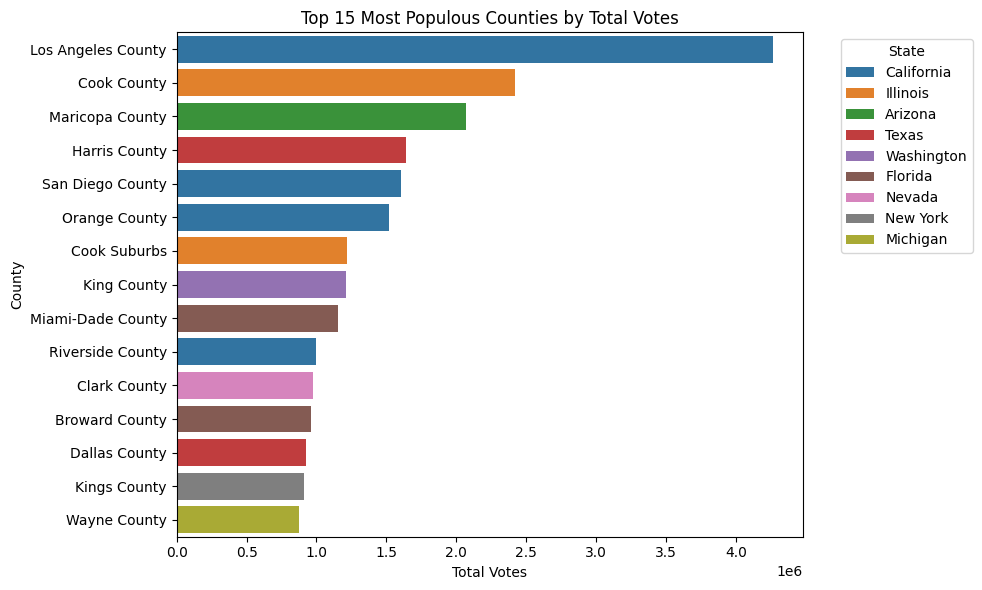

In [20]:
top15_counties = df.nlargest(15, 'total_votes')

plt.figure(figsize=(10, 6))
sns.barplot(data=top15_counties, x='total_votes', y='county', hue='state', dodge=False)
plt.title('Top 15 Most Populous Counties by Total Votes')
plt.xlabel('Total Votes')
plt.ylabel('County')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
totals = df[['total_votes', 'current_votes']].sum()

summary = pd.Series({
    'Total Expected Votes': f"{totals['total_votes']:,}",
    'Total Counted Votes': f"{totals['current_votes']:,}",
    'Counting Progress (%)': f"{(totals['current_votes'] / totals['total_votes']) * 100:.2f}%",
    'Total Remaining Votes': f"{totals['total_votes'] - totals['current_votes']:,}"
})
summary

Total Expected Votes     159,767,210
Total Counted Votes      159,608,237
Counting Progress (%)         99.90%
Total Remaining Votes        158,973
dtype: object

<Axes: title={'center': 'National Voting Progress'}>

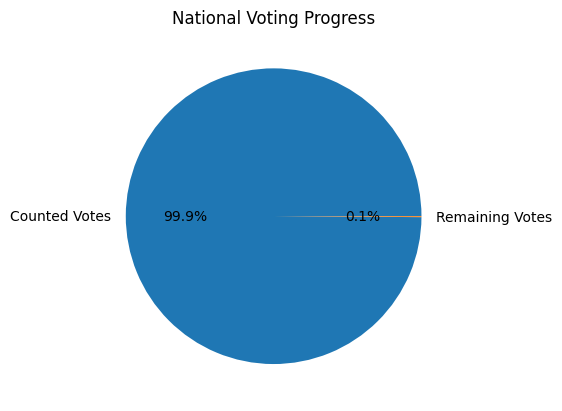

In [25]:
s = pd.Series({
    'Counted Votes': totals['current_votes'],
    'Remaining Votes': totals['total_votes'] - totals['current_votes']
})

s.plot.pie(autopct='%.1f%%', ylabel='', title='National Voting Progress')

In [26]:
df1=pd.read_csv('president_county_candidate.csv')

In [27]:
df1.head()

,state,county,candidate,party,total_votes,won
0,Delaware,Kent County,Joe Biden,DEM,44552,True
1,Delaware,Kent County,Donald Trump,REP,41009,False
2,Delaware,Kent County,Jo Jorgensen,LIB,1044,False
3,Delaware,Kent County,Howie Hawkins,GRN,420,False
4,Delaware,New Castle County,Joe Biden,DEM,195034,True


In [28]:
df1.tail()

,state,county,candidate,party,total_votes,won
32172,Arizona,Maricopa County,Write-ins,WRI,1331,False
32173,Arizona,Mohave County,Donald Trump,REP,78535,True
32174,Arizona,Mohave County,Joe Biden,DEM,24831,False
32175,Arizona,Mohave County,Jo Jorgensen,LIB,1302,False
32176,Arizona,Mohave County,Write-ins,WRI,37,False


In [29]:
df.shape

(4633, 5)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4633 entries, 0 to 4632
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   state          4633 non-null   object
 1   county         4633 non-null   object
 2   current_votes  4633 non-null   int64 
 3   total_votes    4633 non-null   int64 
 4   percent        4633 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 181.1+ KB


In [31]:
df.isnull().sum()

state            0
county           0
current_votes    0
total_votes      0
percent          0
dtype: int64

In [32]:
df.describe()

,current_votes,total_votes,percent
count,4.633000e+03,4.633000e+03,4633.000000
mean,3.445030e+04,3.448461e+04,99.579754
std,1.244014e+05,1.249112e+05,1.807009
min,0.000000e+00,0.000000e+00,69.000000
25%,2.327000e+03,2.326000e+03,100.000000
50%,7.765000e+03,7.695000e+03,100.000000
75%,2.034600e+04,2.034600e+04,100.000000
max,4.263443e+06,4.263443e+06,100.000000


In [33]:
df.corr(numeric_only=True)

,current_votes,total_votes,percent
current_votes,1.000000,0.999901,0.006204
total_votes,0.999901,1.000000,0.004472
percent,0.006204,0.004472,1.000000


In [34]:
df.columns

Index(['state', 'county', 'current_votes', 'total_votes', 'percent'], dtype='object')

In [44]:
df['state'].value_counts()

state
Maine                   498
Massachusetts           351
Texas                   254
Vermont                 246
New Hampshire           237
Connecticut             169
Georgia                 159
Virginia                133
Kentucky                120
Missouri                115
Kansas                  105
Illinois                103
North Carolina          100
Iowa                     99
Tennessee                95
Nebraska                 93
Indiana                  92
Ohio                     88
Minnesota                87
Michigan                 83
Mississippi              82
Oklahoma                 77
Arkansas                 75
Wisconsin                72
Pennsylvania             67
Alabama                  67
Florida                  67
South Dakota             66
Louisiana                64
Colorado                 64
New York                 62
California               58
Montana                  56
West Virginia            55
North Dakota             53
South Carolina

<Axes: title={'center': 'Count of Records by State'}, ylabel='state'>

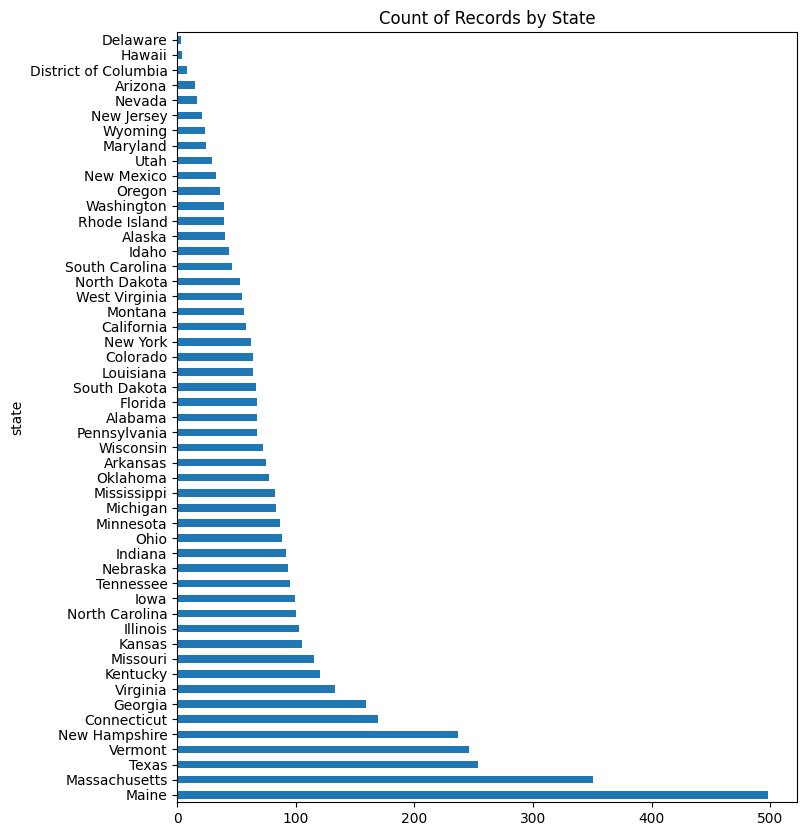

In [45]:
df['state'].value_counts().plot.barh(figsize=(8, 10), title='Count of Records by State')

<Axes: title={'center': 'Top 5 Candidates by Total Votes'}, xlabel='candidate'>

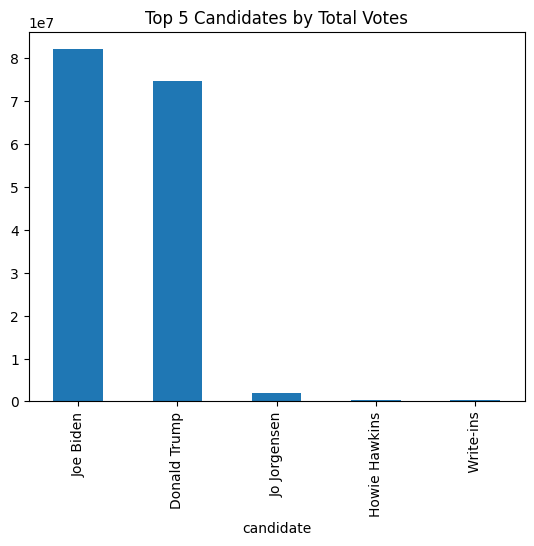

In [35]:
df1.groupby('candidate')['total_votes'].sum().nlargest(5).plot.bar(title='Top 5 Candidates by Total Votes')

<Axes: title={'center': 'Votes by Top Parties'}>

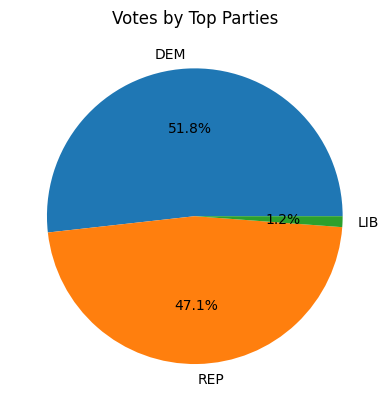

In [42]:
df1.groupby('party')['total_votes'].sum().nlargest(3).plot.pie(autopct='%.1f%%', ylabel='', title='Votes by Top Parties')

<Axes: title={'center': 'Counties Won by Candidate'}, ylabel='candidate'>

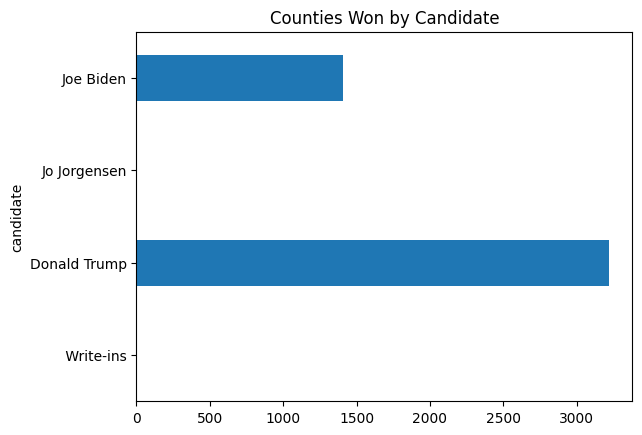

In [37]:
df1[df1['won']].groupby('candidate')['county'].count().plot.barh(title='Counties Won by Candidate')

<Axes: title={'center': 'Top 10 States by Total Votes'}, xlabel='state'>

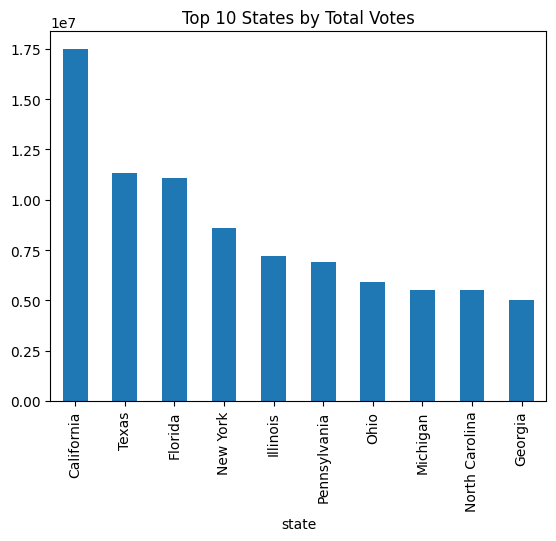

In [38]:
df1.groupby('state')['total_votes'].sum().nlargest(10).plot.bar(title='Top 10 States by Total Votes')

<Axes: title={'center': 'total_votes'}, xlabel='party'>

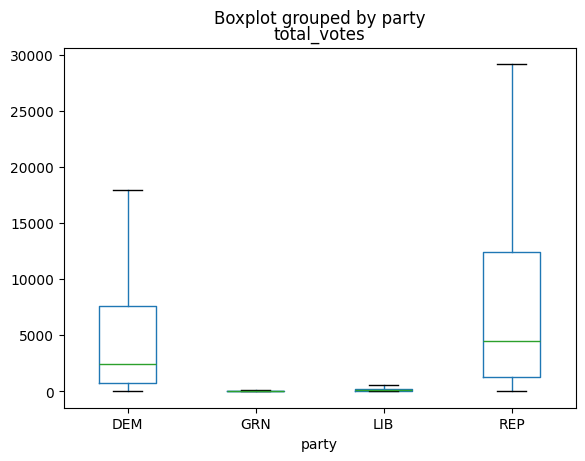

In [43]:
main_parties = ['DEM', 'REP', 'LIB', 'GRN']
df1[df1['party'].isin(main_parties)].boxplot(column='total_votes', by='party', grid=False, showfliers=False)

array([[<Axes: xlabel='total_votes', ylabel='total_votes'>,
        <Axes: xlabel='won', ylabel='total_votes'>],
       [<Axes: xlabel='total_votes', ylabel='won'>,
        <Axes: xlabel='won', ylabel='won'>]], dtype=object)

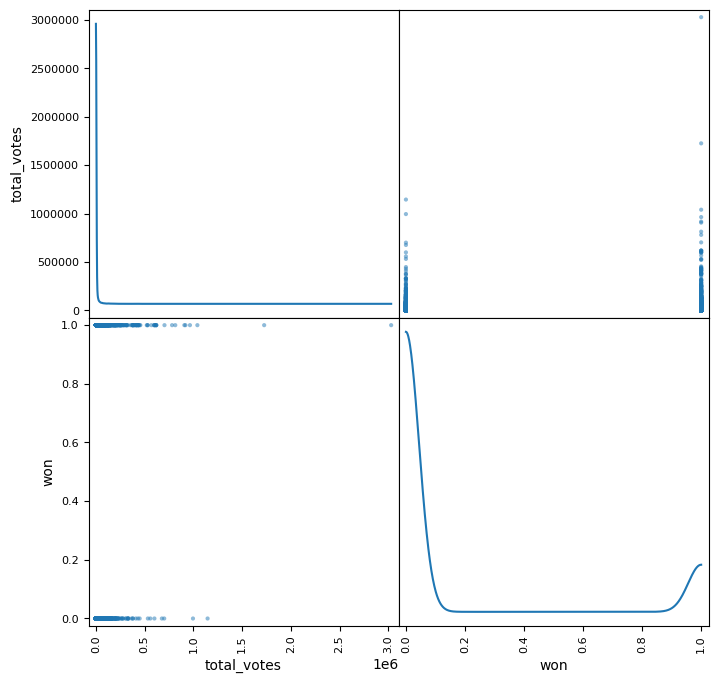

In [47]:
pd.plotting.scatter_matrix(df1[['total_votes', 'won']].astype(int), alpha=0.5, figsize=(8, 8), diagonal='kde')

<Axes: title={'center': 'Cumulative Votes by Party across States'}, xlabel='state'>

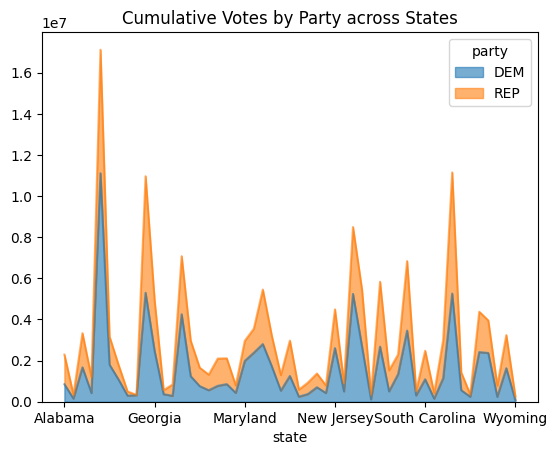

In [48]:
df1[df1['party'].isin(['DEM', 'REP'])].pivot_table(index='state', columns='party', values='total_votes', aggfunc='sum').plot.area(title='Cumulative Votes by Party across States', alpha=0.6)

<Axes: title={'center': 'Vote Density vs Victory Status'}, xlabel='won_num', ylabel='total_votes'>

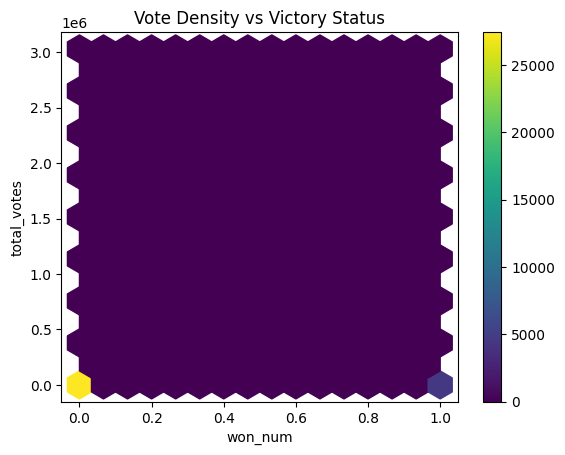

In [50]:
df1.assign(won_num=df1['won'].astype(int)).plot.hexbin(x='won_num', y='total_votes', gridsize=15, cmap='viridis', title='Vote Density vs Victory Status')

<Axes: >

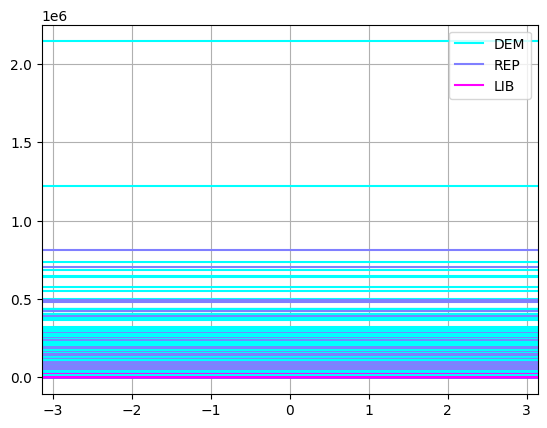

In [51]:
pd.plotting.andrews_curves(df1[df1['party'].isin(['DEM', 'REP', 'LIB'])][['party', 'total_votes', 'won']], 'party', colormap='cool')

<Axes: >

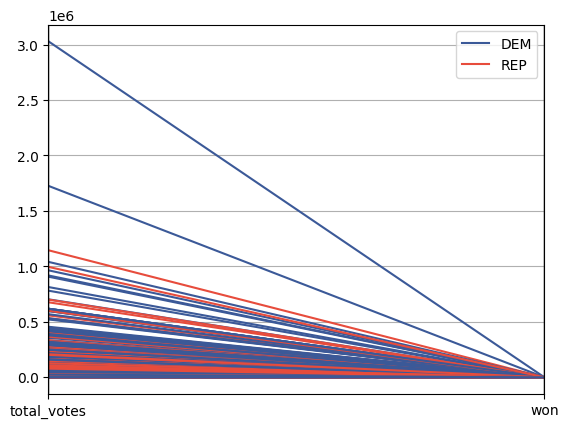

In [52]:
pd.plotting.parallel_coordinates(df1[df1['party'].isin(['DEM', 'REP'])][['party', 'total_votes', 'won']], 'party', color=['#3b5998', '#e74c3c'])

The visual insights confirm that total vote volume varies significantly by state, while candidate performance remains heavily aligned with major party lines.